## Imports- directly read and write from sqlite
* [tutorial](https://www.jeremymorgan.com/tutorials/python-tutorials/how-to-matplotlib-python/)

## DB streamline/redesign:
* (*method)

```text
DATABASE.sqlite3
|
├── parameters
|   |-- gui TEXT
|   |-- experiment TEXT
|   ...
|   |-- 'omega_scaled' REAL (*method* for calculating last 3)
|   |-- 'dt' REAL
|   |-- 'f_s' REAL
│
├── acoustics
│   ├── collection_index INTEGER 
│   ├── X REAL
│   ├── Z REAL
│   ├── time REAL
|   |-- frequency REAL (*method* for calculating)
│   ├── voltage BLOB (* method for getting key names)
|   ... multiple scans from multiplexer
│
|── analysis (*method* to write table. collection_index as PK)
|   ├── collection_index INTEGER  (same as acoustics table)
|   ├── waveform TEXT (select from column name in acoustics. i.e. voltage, voltage_echo_forward... )
|   ├── analysis_name TEXT (*method* for each. i.e. filter, ungain, hilbert, fft, cwt, correlation )
|   |-- result_name TEXT (ie raw, magnitude, phase, group_velocity) (*method)
|   ├── value BLOB (array)
|   ├── x_axis TEXT (ie time, freq)
|   |── x_unit TEXT (ie ns, Hz)
|   |── y_unit TEXT (ie mV, Hz)
|   |-- reference_id INTEGER 
|
|-- analysis_reference (*method* for constructing)
|   |-- reference_id INTEGER (use as idx)
|   |-- analysis_name TEXT (ie, cwt, correlation, fft)
|   |-- reference_name TEXT (ie filename, 'cmor0.5-1.0') 
|   |-- value BLOB (*method* to read in a water waveform, scale, interp), (*method* upload from cwt)
|   |-- metadata TEXT (ie kwargs to calculate in function)
|
|--controller (*method* translate merging and filtering methods from csv. Reference gradient_helpers.py)
|   |-- collection_index
|   ...
...
```

In [7]:
%load_ext autoreload
%autoreload 2

import os
import sys
import sqlite3
sys.path.append('..')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')

import numpy as np
import pywt
from tqdm import tqdm
from matplotlib import pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks

from ultrasonic_ml.viz import sqlite_clickable_viewer as viz



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# w front wall
# sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_back_pulseecho_150_32mm_1mm_0_02_voltrange.sqlite3'

# wo front wall
# sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.sqlite3'

sqlite_file = '/Users/xz498/Downloads/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.sqlite3'

In [9]:
import sqliteUtils as squ
import database as db

database = db.Loaded_Database(sqlite_file)

In [13]:
squ.columnNames(database.cursor, 'parameters')

['gui',
 'experiment',
 'axis',
 'distance',
 'transducerFrequency',
 'collectionMode',
 'pulserType',
 'measureTime',
 'measureDelay',
 'voltageRange',
 'autoRange',
 'autoRangeEcho',
 'waves',
 'samples',
 'halfCycles',
 'multiplexer',
 'collectionDirection',
 'voltageOffsetForward',
 'voltageOffsetReverse',
 'gainForward',
 'gainReverse',
 'picoModule',
 'pulseModule',
 'rfSwitch',
 't0PulseSwitch',
 't0ReceiveSwitch',
 't1PulseSwitch',
 't1ReceiveSwitch',
 'experimentFolder',
 'experimentName',
 'experimentBaseName',
 'saveFormat',
 'postAnalysis',
 'primaryAxis',
 'secondaryAxis',
 'primaryAxisRange',
 'primaryAxisStep',
 'secondaryAxisRange',
 'secondaryAxisStep',
 'scanInterval',
 'numberOfScans',
 'pulseInterval',
 'experimentTime',
 'sweepParams',
 'pulserPort',
 'scannerPort',
 'dllFile',
 'multiplexerPort',
 'transducerHolderHeight',
 'scannerMaxDimensions',
 'fileName',
 'omega_scaled',
 'dt',
 'f_s']

squ.columnNames(database.cursor, 'parameters')

In [10]:
database.init_write_frequency_parameters()

Error creating new column omega_scaled in table parameters. Column likely already exists. Data will be overwritten
Error creating new column dt in table parameters. Column likely already exists. Data will be overwritten
Error creating new column f_s in table parameters. Column likely already exists. Data will be overwritten


In [11]:
database.filter_voltages()

Error creating new column voltage_filtered in table acoustics. Column likely already exists. Data will be overwritten


100%|██████████| 4983/4983 [00:01<00:00, 3270.52it/s]


In [12]:
database.maxes_voltages()

100%|██████████| 4983/4983 [00:00<00:00, 18292.37it/s]


In [14]:
%matplotlib widget

import matplotlib.pyplot as plt

from ultrasonic_ml.viz import sqlite_clickable_viewer as viz

viewer = viz.AcousticsSpectralSpatialViewer(database)
fig, (ax_img, ax_spec) = viewer.build_clickable_figure()

plt.show()

NameError: name 'sqlite3' is not defined

(<Figure size 1400x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Spatial Spectral Peak Frequency'}, xlabel='x (mm)', ylabel='z (mm)'>,
         <Axes: title={'center': 'Waveform | collection_index=3000 | x=131.00 mm | z=-19.00 mm'}, xlabel='Time (us)', ylabel='Voltage'>],
        [<Axes: title={'center': 'Spatial Band Energy Ratio (2.00e+06-2.50e+06 Hz)'}, xlabel='x (mm)', ylabel='z (mm)'>,
         <Axes: title={'center': 'Spectrum | collection_index=3000'}, xlabel='Frequency (Hz)', ylabel='Magnitude (dB)'>]],
       dtype=object))

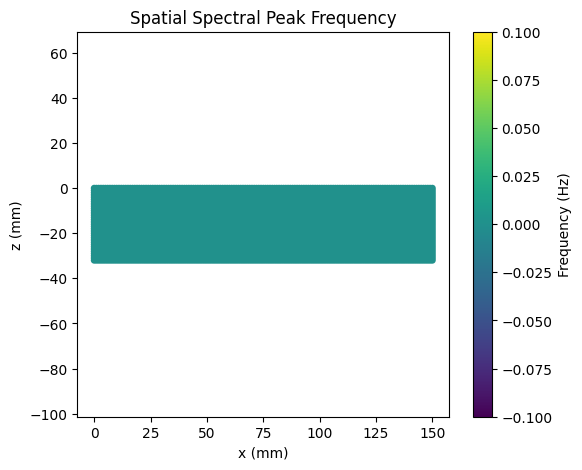

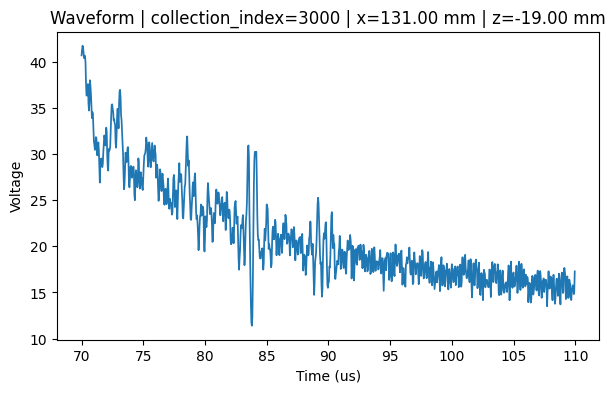

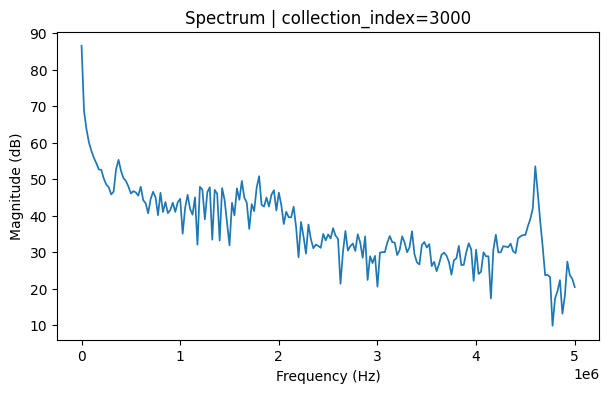

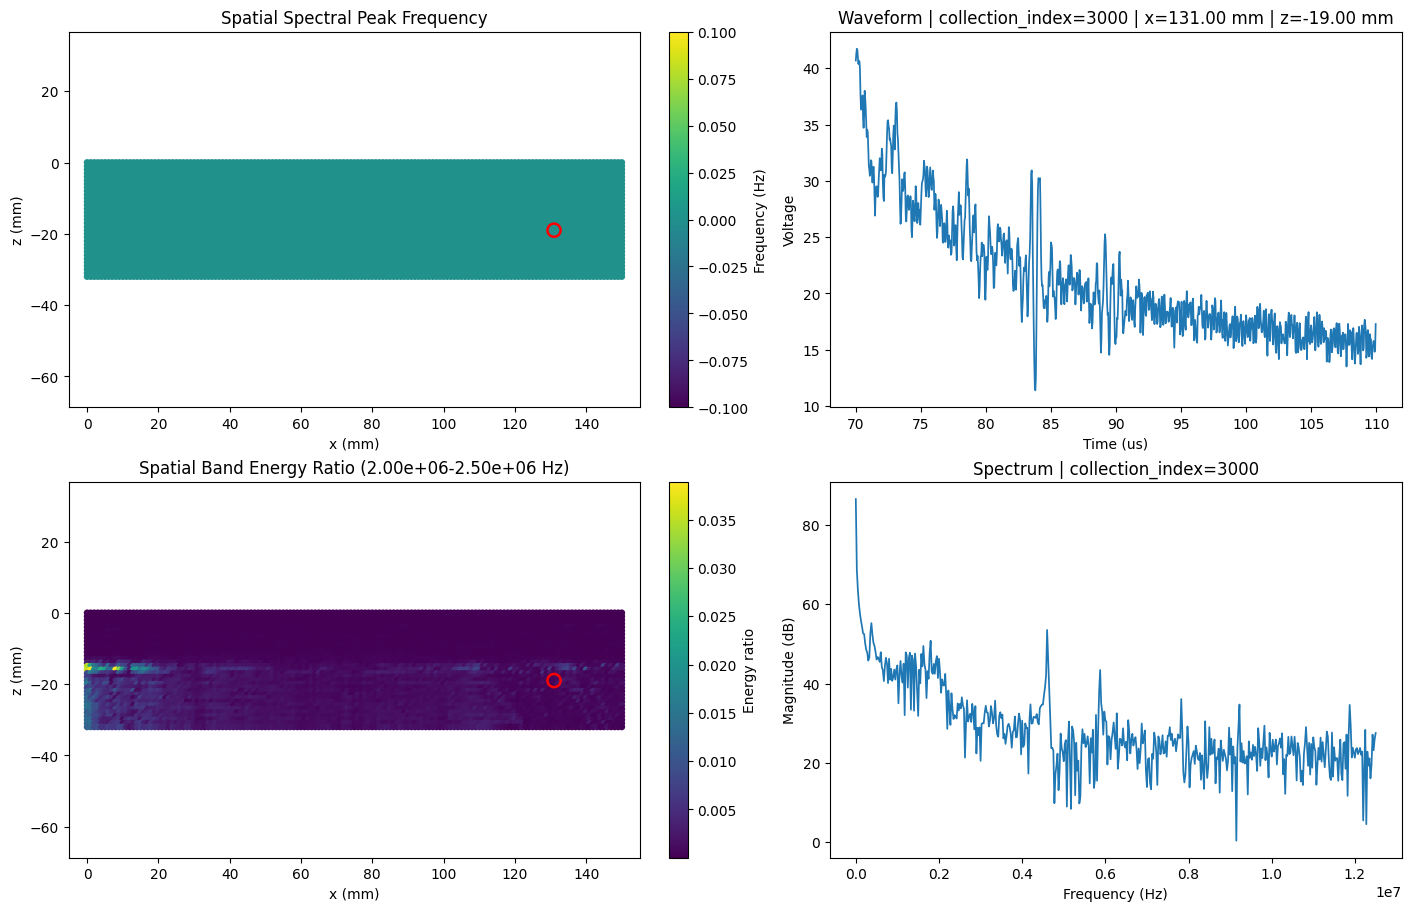

In [66]:
prw.plot_spatial_metric(database, metric="peak_freq");
prw.plot_waveform(database, collection_index=3000);
prw.plot_spectrum(database, collection_index=3000, max_hz=5e6);
prw.plot_spatial_spectral_dashboard(database, collection_index=3000, band_hz=(2.0e6, 2.5e6))

## preprocess and calculate transforms

In [ ]:
# i = 3000
i = min(3000, measurement_ids[-1])
waveform = gh_sql.read_array(db, i, 'voltage_preprocessed')
plt.plot(time, waveform, label='bandpass filtering')
plt.legend()
plt.show()

In [ ]:
wavelet = 'cmor0.5-1.0'
freqs_of_interest = np.linspace(100e3, 4e6, 100)
central_freq = pywt.central_frequency(wavelet)
scales = central_freq * fs / freqs_of_interest
freqs_hz = pywt.scale2frequency(wavelet, scales) * fs

i = min(3000, measurement_ids[-1])
waveform = gh_sql.read_array(db, i, 'voltage_preprocessed')
coeffs, _ = pywt.cwt(waveform, scales, wavelet, sampling_period=dt)
mag_ = np.abs(coeffs)

In [ ]:
# Calculate and store CWT coefficients directly in SQLite.
for measurement_id in tqdm(measurement_ids):
    waveform = gh_sql.read_array(db, measurement_id, 'voltage_preprocessed')
    coefficients, _ = pywt.cwt(waveform, scales, wavelet, sampling_period=dt)
    gh_sql.write_array(db, measurement_id, 'morlet_cwt', coefficients)
db.commit()

100%|██████████| 4983/4983 [02:06<00:00, 39.32it/s]


In [ ]:
# Calculate and store CWT magnitudes directly in SQLite.
for measurement_id in tqdm(measurement_ids):
    coefficients = gh_sql.read_array(db, measurement_id, 'morlet_cwt')
    gh_sql.write_array(db, measurement_id, 'morlet_cwt_magnitude', np.abs(coefficients))
db.commit()

100%|██████████| 4983/4983 [00:47<00:00, 105.52it/s]


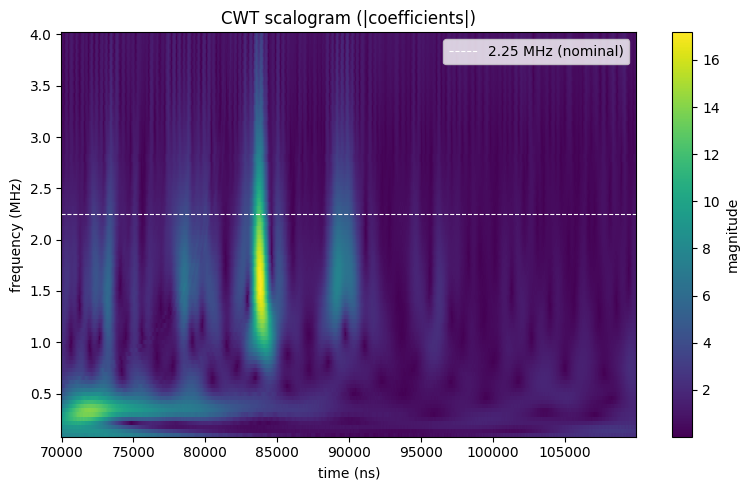

In [ ]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(time, freqs_hz / 1e6, mag_, shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (|coefficients|)')
plt.colorbar(label='magnitude')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
freq_center = 2.25e6
band_frac = 0.05
band_mask = (freqs_hz >= freq_center * (1 - band_frac)) & (freqs_hz <= freq_center * (1 + band_frac))
freq_window = freqs_hz[band_mask]

profile_ = np.max(mag_[band_mask], axis=0)
peaks, _ = find_peaks(profile_, prominence=0.1 * profile_.max())
peak_inds = peaks[np.argsort(profile_[peaks])][::-1]

In [ ]:
# Store the band-pass profile for every measurement in SQLite.
for measurement_id in tqdm(measurement_ids):
    magnitude = gh_sql.read_array(db, measurement_id, 'morlet_cwt_magnitude')
    gh_sql.write_array(db, measurement_id, 'morlet_bandpass_profile', np.max(magnitude[band_mask], axis=0))
db.commit()

In [ ]:
def get_peak_times(profile):
    peaks, _ = find_peaks(profile, prominence=0.1 * profile.max())
    return peaks

# Store detected peak indices as SQLite arrays.
for measurement_id in tqdm(measurement_ids):
    profile = gh_sql.read_array(db, measurement_id, 'morlet_bandpass_profile')
    gh_sql.write_array(db, measurement_id, 'morlet_cwt_peak_inds', get_peak_times(profile))
db.commit()

100%|██████████| 4983/4983 [00:00<00:00, 11931.41it/s]


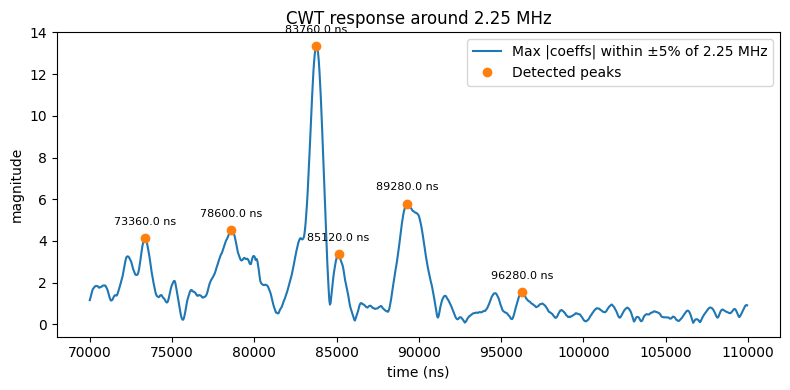

In [ ]:
i = min(3000, measurement_ids[-1])
profile_ = gh_sql.read_array(db, i, 'morlet_bandpass_profile')
peak_inds = gh_sql.read_array(db, i, 'morlet_cwt_peak_inds').astype(int)

plt.figure(figsize=(8, 4))
plt.plot(time, profile_, label=f'Max |coeffs| within ±{band_frac * 100:.0f}% of {freq_center / 1e6:.2f} MHz')
plt.plot(time[peak_inds], profile_[peak_inds], 'o', label='Detected peaks')
for x, y in zip(time[peak_inds], profile_[peak_inds]):
    plt.annotate(f'{x:.1f} ns', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('time (ns)')
plt.ylabel('magnitude')
plt.title('CWT response around 2.25 MHz')
plt.legend()
plt.tight_layout()
plt.show()

I'm still figuring out exactly what the phase and group delay mean in a cwt so maybe you don't have to include this...

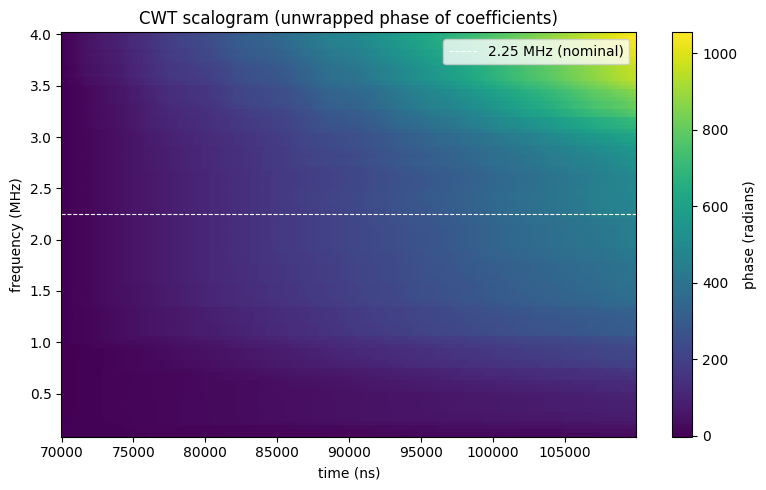

In [ ]:
coeffs = gh_sql.read_array(db, i, 'morlet_cwt')
phase = np.unwrap(np.angle(coeffs))

plt.figure(figsize=(8, 5))
plt.pcolormesh(time, freqs_hz / 1e6, phase, shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (unwrapped phase of coefficients)')
plt.colorbar(label='phase (radians)')
plt.legend()
plt.tight_layout()
plt.show()

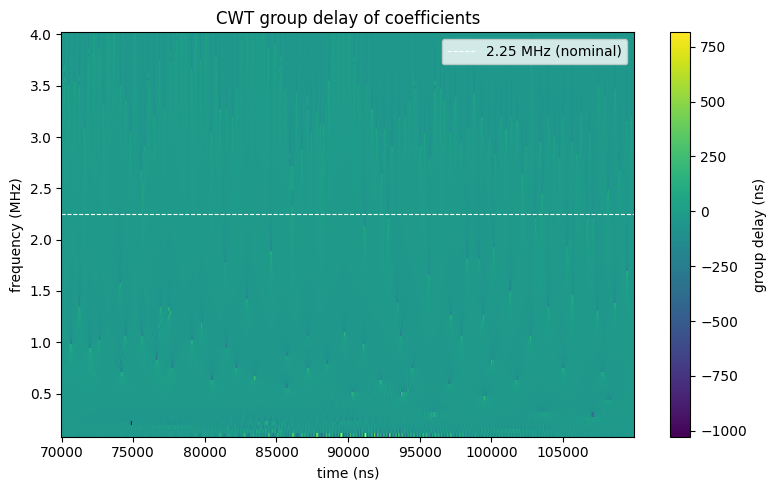

In [ ]:
group_delay = -np.gradient(phase, axis=1) / (2 * np.pi * freqs_hz[:, np.newaxis]) * 1e9

plt.figure(figsize=(8, 5))
plt.pcolormesh(time, freqs_hz / 1e6, group_delay, shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT group delay of coefficients')
plt.colorbar(label='group delay (ns)')
plt.legend()
plt.tight_layout()
plt.show()